# Restaurant Visitors Forecasting Using SARIMAX

### Objective
Forecast daily restaurant visitors using time-series forecasting techniques and evaluate the model using MAPE and MSE.

### Business Objective
Accurate visitor forecasting can help restaurants with:
- Staff scheduling
- Inventory planning
- Resource allocation
- Operational planning

In [1]:
# importing all libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima
# model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# load datsets
rv=pd.read_csv(r'C:\Users\Admin\Downloads\RestaurantVisitors.csv')
rv.head()

,date,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
0,01-01-2016,Friday,1,New Year's Day,65,25,67,139,296
1,01-02-2016,Saturday,0,na,24,39,43,85,191
2,01-03-2016,Sunday,0,na,24,31,66,81,202
3,01-04-2016,Monday,0,na,23,18,32,32,105
4,01-05-2016,Tuesday,0,na,2,15,38,43,98


In [3]:
print("Dataset Shape:", rv.shape)

Dataset Shape: (478, 9)


In [4]:
# Check_Columns
rv.columns

Index(['date', 'weekday', 'holiday', 'holiday_name', 'rest1', 'rest2', 'rest3',
       'rest4', 'total'],
      dtype='object')

In [5]:
# dataset Information
rv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          478 non-null    object
 1   weekday       478 non-null    object
 2   holiday       478 non-null    int64 
 3   holiday_name  478 non-null    object
 4   rest1         478 non-null    int64 
 5   rest2         478 non-null    int64 
 6   rest3         478 non-null    int64 
 7   rest4         478 non-null    int64 
 8   total         478 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 33.7+ KB


In [6]:
rv.describe()

,holiday,rest1,rest2,rest3,rest4,total
count,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000
mean,0.066946,37.533473,27.163180,31.548117,37.548117,133.792887
std,0.250190,21.499791,15.731851,17.820112,24.614955,59.736116
min,0.000000,1.000000,1.000000,6.000000,3.000000,40.000000
25%,0.000000,22.250000,15.000000,18.000000,19.000000,86.000000
50%,0.000000,33.000000,25.000000,24.000000,30.000000,119.000000
75%,0.000000,49.000000,38.000000,45.000000,50.000000,176.750000
max,1.000000,128.000000,91.000000,99.000000,139.000000,316.000000


In [7]:
# Check Nulls
rv.isnull().sum()[rv.isnull().sum()>1]

Series([], dtype: int64)

In [8]:
# drop unnecessary  columns 
rv = rv.drop(columns=['rest1', 'rest2', 'rest3', 'rest4', 'holiday_name'])

In [9]:
rv.columns

Index(['date', 'weekday', 'holiday', 'total'], dtype='object')

In [10]:
# convert date to to_datetime
rv['date'] = pd.to_datetime(rv['date'],  format='mixed' )
#  format mixed  --> dd/mm/ yyyy
#                    mm/dd/yyyy

In [11]:
rv = rv.sort_values('date')

In [12]:
# set date as index
rv = rv.set_index(['date'])

In [13]:
# EDA 

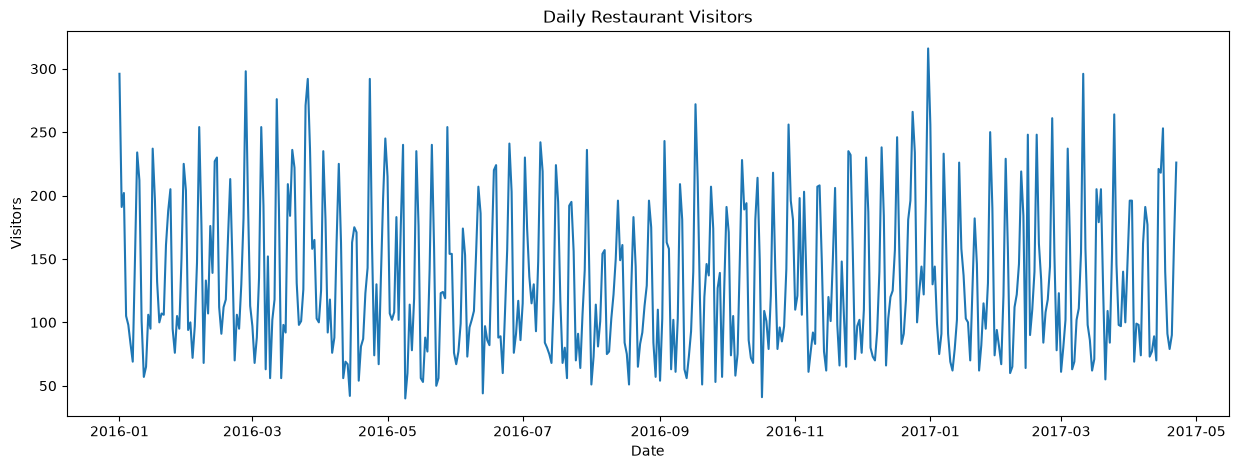

In [14]:
plt.figure(figsize=(15,5))
plt.plot(rv.index, rv['total'])
plt.title("Daily Restaurant Visitors")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.show()

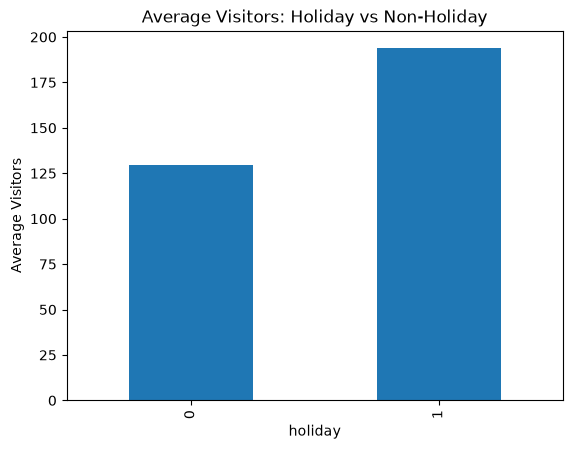

In [15]:
rv.groupby('holiday')['total'].mean().plot(kind='bar')
plt.title("Average Visitors: Holiday vs Non-Holiday")
plt.ylabel("Average Visitors")
plt.show()

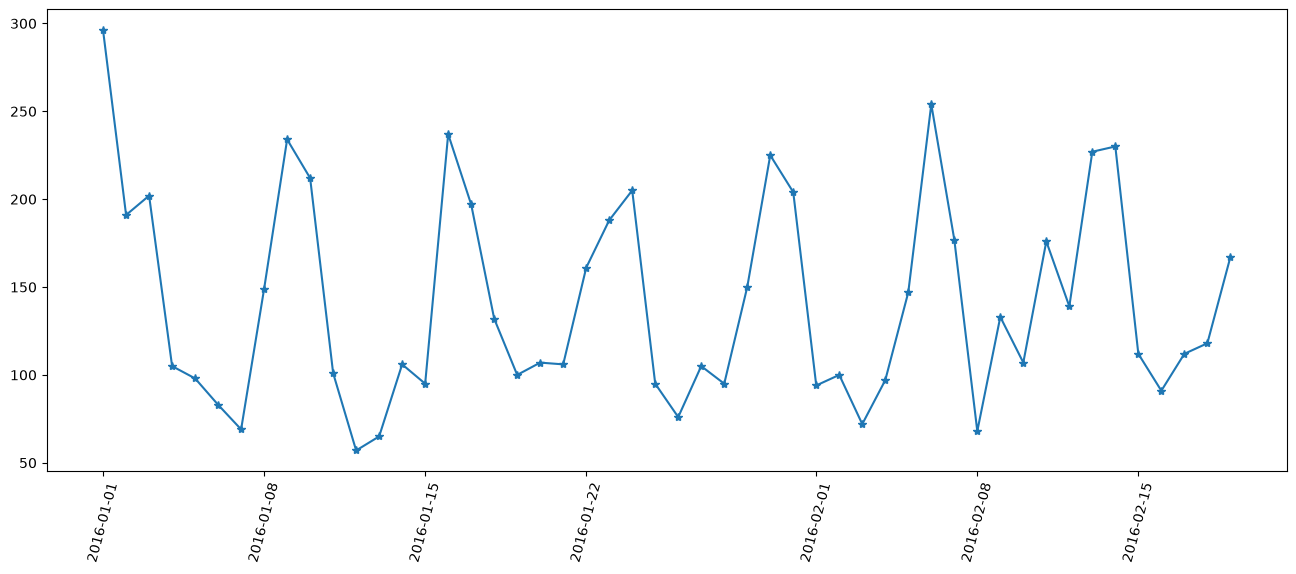

In [16]:
plt.figure(figsize=(16,6))
plt.plot(rv.total[0:50], marker ="*") # 1st 50 values
plt.xticks(rotation = 75);

* Data is Stationary
* Data is seasonal , m = 7 days

In [17]:
# ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf

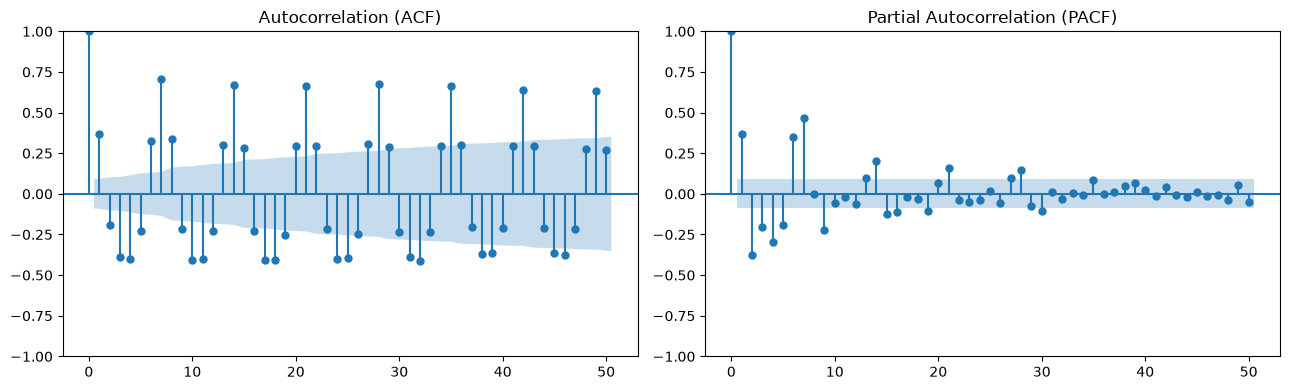

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(rv['total'], lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')
plot_pacf(rv['total'], lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()

In [19]:
# Checking Stationary 

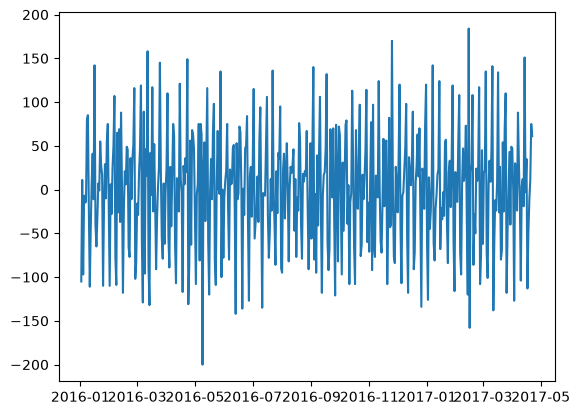

In [20]:
plt.plot(rv['total'].diff()) # level 1 of Differencing 

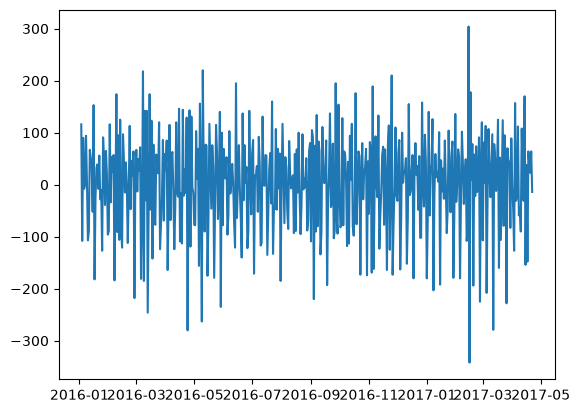

In [21]:
plt.plot(rv['total'].diff().diff()) # Level 2 of Differencing

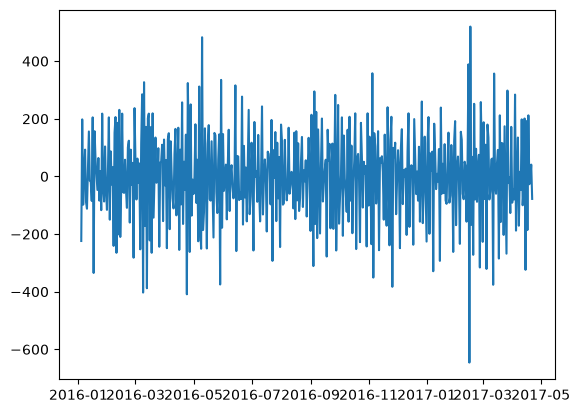

In [22]:
plt.plot(rv['total'].diff().diff().diff()) # Level 3 of Differencing

In [23]:
# train test Split

In [24]:
# Divide data into train and test
# random sampling is not possible on Time series --> sequnce is needed 

In [25]:
rv_train = rv.iloc[0:440] # 1st 440 in train
rv_test  = rv.iloc[440::] # last 38 in test data 

In [26]:
rv_train.shape

(440, 3)

In [27]:
rv_test.shape

(38, 3)

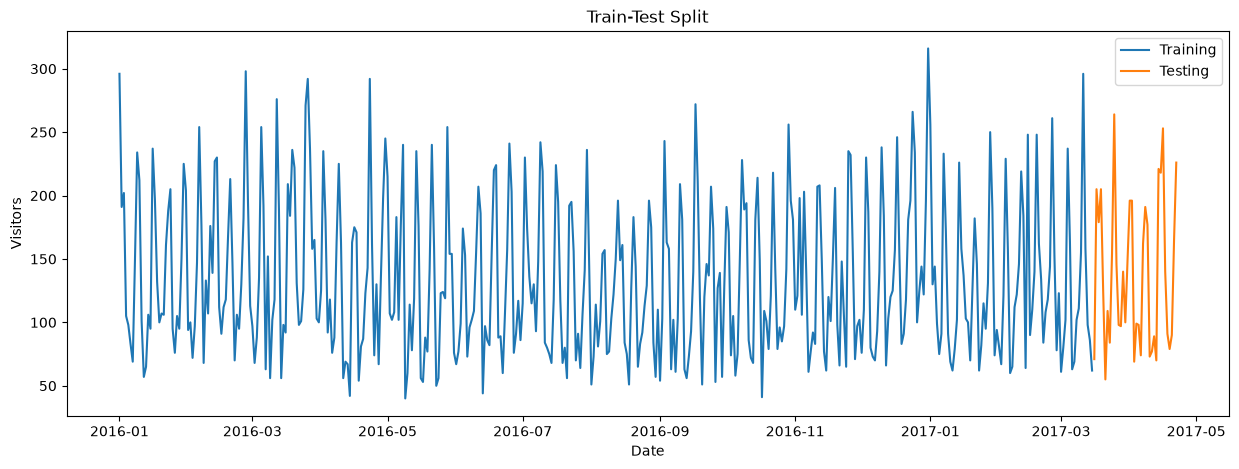

In [28]:
plt.figure(figsize=(15,5))

plt.plot(rv_train.index, rv_train['total'], label='Training')
plt.plot(rv_test.index, rv_test['total'], label='Testing')

plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Visitors")

plt.legend()
plt.show()

# Auto arima
* auto arima provides values of  p,d,q --->  these values are used in SARIMAX
* sarimax can be used to build any type of model by controling the values of 
* P,D,Q, X
* if series is having seasonality use the option  seasonal=True and pass the seasonal time period 

In [29]:
model = auto_arima(rv['total'], seasonal=True , m=7)

In [30]:
model.get_params

<bound method BaseEstimator.get_params of ARIMA(order=(0, 0, 0), scoring_args={}, seasonal_order=(1, 0, 1, 7),
      suppress_warnings=True)>

In [31]:
print("Order:", model.order)
print("Seasonal Order:", model.seasonal_order)

Order: (0, 0, 0)
Seasonal Order: (1, 0, 1, 7)


In [32]:
import warnings
warnings.filterwarnings('ignore')
model1 = SARIMAX(rv_train['total'], order=(0, 0, 0), seasonal_order=(1, 0, 1, 7))
results = model1.fit() # model is created 

In [33]:
pred_rv = results.predict(start= 440 , end= 477)

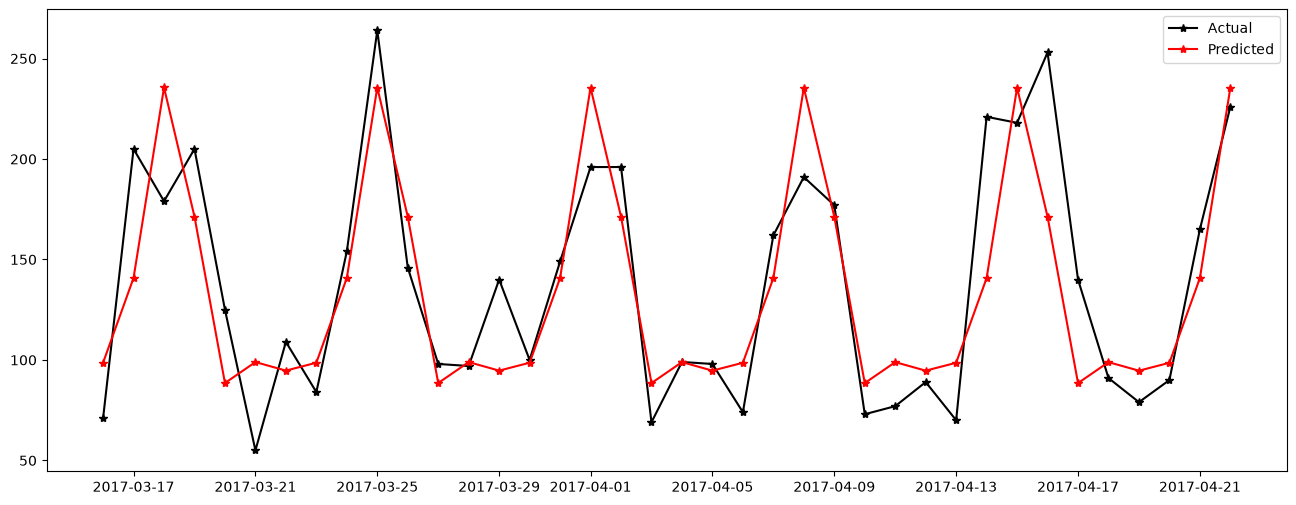

In [34]:
# plt actual and predicted values
plt.figure(figsize=(16,6))
plt.plot(rv_test['total'], marker='*', color='black', label='Actual')
plt.plot(pred_rv, marker='*', color='red', label='Predicted')
plt.legend()

* Above model was SARIMA model
* Model has issue with holiday when there is holiday model is not so good

In [35]:
rv_test['pred_sarima'] = round(pred_rv)
# adding a new column in test data 

In [36]:
#  just to compare forecasted value on holidays 
# for holidays model is doing huge under prediction of around( 35 to 40 %)

# SARIMA  MODEL IS UNDER PERFORMING FOR HOLIDAYS( EXTERNAL FACTOR)
rv_test[rv_test.holiday == 1]

,weekday,holiday,total,pred_sarima
date,,,,
2017-03-17,Friday,1,205,141.0
2017-04-14,Friday,1,221,141.0
2017-04-16,Sunday,1,253,171.0
2017-04-17,Monday,1,140,88.0


In [37]:
# Model evaluation for SARIMA

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
sarima_mae = mean_absolute_error(rv_test['total'], pred_rv)
sarima_rmse = np.sqrt(mean_squared_error(rv_test['total'], pred_rv))
sarima_mape = mean_absolute_percentage_error(rv_test['total'], pred_rv)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'Value': [
        f'{sarima_mae:.2f}',
        f'{sarima_rmse:.2f}',
        f'{sarima_mape:.2%}']})

metrics_df

,Metric,Value
0,MAE,25.70
1,RMSE,32.88
2,MAPE,19.74%


# SARIMAX model
* Pass the data for x factors
* Pass data for exog

In [39]:
model1 = auto_arima(rv['total'], seasonal=True , m=7 , exogenous= rv['holiday'] )

In [40]:
model1.get_params

<bound method BaseEstimator.get_params of ARIMA(order=(0, 0, 0), scoring_args={}, seasonal_order=(1, 0, 1, 7),
      suppress_warnings=True)>

In [41]:
print("Order:", model.order)
print("Seasonal Order:", model.seasonal_order)

Order: (0, 0, 0)
Seasonal Order: (1, 0, 1, 7)


In [42]:
model2 = SARIMAX(rv_train['total'], order=(0, 0, 0),exog=rv_train[['holiday']], seasonal_order=(1, 0, 1, 7))
result2 = model2.fit()

In [43]:
pred_rv1 =result2.predict(start= 440 , end= 477, exog=rv_test[['holiday']])

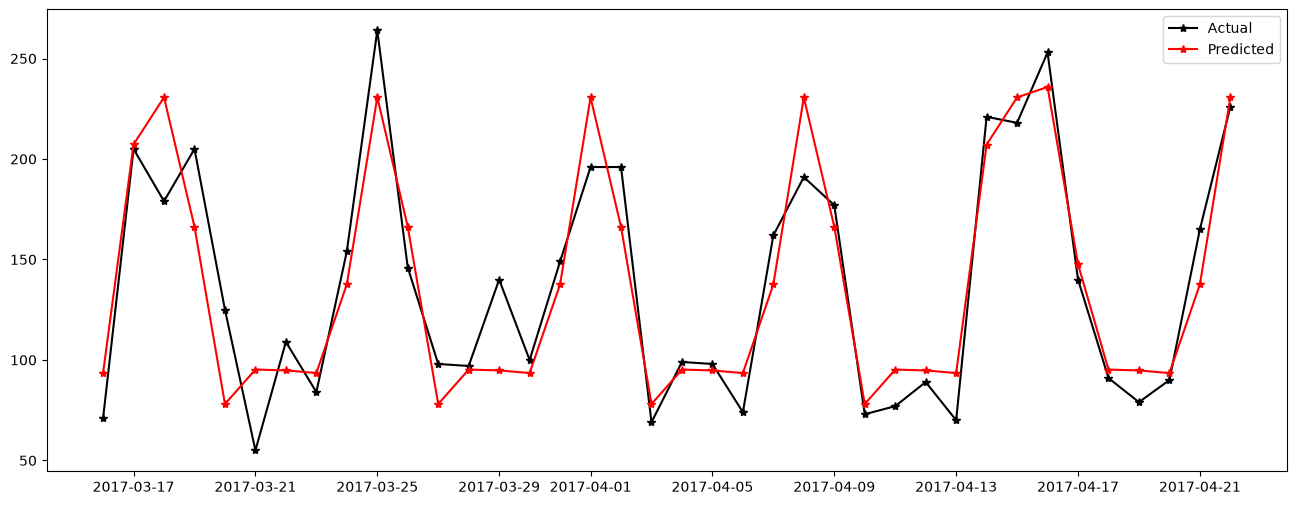

In [44]:
plt.figure(figsize=(16,6))
plt.plot(rv_test['total'], marker='*', color='black', label='Actual')
plt.plot(pred_rv1, marker='*', color='red', label='Predicted')
plt.legend()

In [45]:
rv_test['pred_sarimax'] =round(pred_rv1)

In [46]:
rv_test[rv_test.holiday == 1]

,weekday,holiday,total,pred_sarima,pred_sarimax
date,,,,,
2017-03-17,Friday,1,205,141.0,207.0
2017-04-14,Friday,1,221,141.0,207.0
2017-04-16,Sunday,1,253,171.0,236.0
2017-04-17,Monday,1,140,88.0,148.0


### Interpretation

The SARIMAX model was evaluated on 38 unseen observations. The predicted values follow the overall pattern of actual restaurant visitors, indicating that the model captures important temporal patterns in visitor demand.

In [47]:
# Model evaluation for SARIMAX

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
sarimax_mae = mean_absolute_error(rv_test['total'], pred_rv1)
sarimax_rmse = np.sqrt(mean_squared_error(rv_test['total'], pred_rv1))
sarimax_mape = mean_absolute_percentage_error(rv_test['total'], pred_rv1)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'Value': [
        f'{sarimax_mae:.2f}',
        f'{sarimax_rmse:.2f}',
        f'{sarimax_mape:.2%}']})

metrics_df

,Metric,Value
0,MAE,18.81
1,RMSE,23.37
2,MAPE,15.38%


In [49]:
# comparing both model metrics

comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'SARIMAX'],
    'MAE': [sarima_mae, sarimax_mae],
    'RMSE': [sarima_rmse, sarimax_rmse],
    'MAPE': [sarima_mape, sarimax_mape]})

comparison_df

,Model,MAE,RMSE,MAPE
0,SARIMA,25.698186,32.883070,0.197427
1,SARIMAX,18.808088,23.367996,0.153831


* SARIMAX outperformed SARIMA on the test dataset, achieving lower forecasting error after incorporating holiday information as an exogenous variable. Therefore, SARIMAX was selected as the final model for restaurant visitor forecasting.

In [50]:
# Refit the final SARIMAX model using all available historical data
final_model = SARIMAX(rv['total'], order=(0, 0, 0),exog=rv[['holiday']], seasonal_order=(1, 0, 1, 7))
final_result = final_model.fit()

final_results = final_model.fit()
print(final_results.summary())

                                 SARIMAX Results                                 
Dep. Variable:                     total   No. Observations:                  478
Model:             SARIMAX(1, 0, [1], 7)   Log Likelihood               -2290.874
Date:                   Sat, 22 Aug 2026   AIC                           4589.748
Time:                           20:04:59   BIC                           4606.427
Sample:                       01-01-2016   HQIC                          4596.305
                            - 04-22-2017                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
holiday       69.9545      3.831     18.259      0.000      62.446      77.464
ar.S.L7        1.0000   4.21e-05   2.38e+04      0.000       1.000       1.000
ma.S.L7       -0.9597      0

In [51]:
last_date = rv.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7,
    freq='D')

future_dates

DatetimeIndex(['2017-04-23', '2017-04-24', '2017-04-25', '2017-04-26',
               '2017-04-27', '2017-04-28', '2017-04-29'],
              dtype='datetime64[ns]', freq='D')

In [52]:
future_exog = pd.DataFrame(
    {'holiday': [0, 0, 0, 0, 0, 0, 0]},
    index=future_dates)

future_exog

,holiday
2017-04-23,0
2017-04-24,0
2017-04-25,0
2017-04-26,0
2017-04-27,0
2017-04-28,0
2017-04-29,0


In [53]:
# Generate 7-day ahead visitor forecast

forecast_7_days = final_results.get_forecast(
    steps=7,
    exog=future_exog)

forecast_mean = forecast_7_days.predicted_mean

forecast_mean

2017-04-23    170.395684
2017-04-24     79.734706
2017-04-25     92.343589
2017-04-26     96.106803
2017-04-27     91.202827
2017-04-28    141.875449
2017-04-29    225.419451
Freq: D, Name: predicted_mean, dtype: float64

In [54]:
forecast_ci = forecast_7_days.conf_int()

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Visitors': forecast_mean.values,
    'Lower CI': forecast_ci.iloc[:, 0].values,
    'Upper CI': forecast_ci.iloc[:, 1].values})

forecast_df

,Date,Predicted Visitors,Lower CI,Upper CI
0,2017-04-23,170.395684,115.537800,225.253568
1,2017-04-24,79.734706,24.876822,134.592591
2,2017-04-25,92.343589,37.485705,147.201473
3,2017-04-26,96.106803,41.248919,150.964687
4,2017-04-27,91.202827,36.344943,146.060711
5,2017-04-28,141.875449,87.018204,196.732693
6,2017-04-29,225.419451,170.562207,280.276695


## 7-Day Ahead Restaurant Visitor Forecast

After evaluating the SARIMAX model on the 38-observation test set, the final model was retrained using all available historical data.

The retrained model was then used to forecast restaurant visitors for the next 7 days. Confidence intervals were also generated to quantify forecast uncertainty.

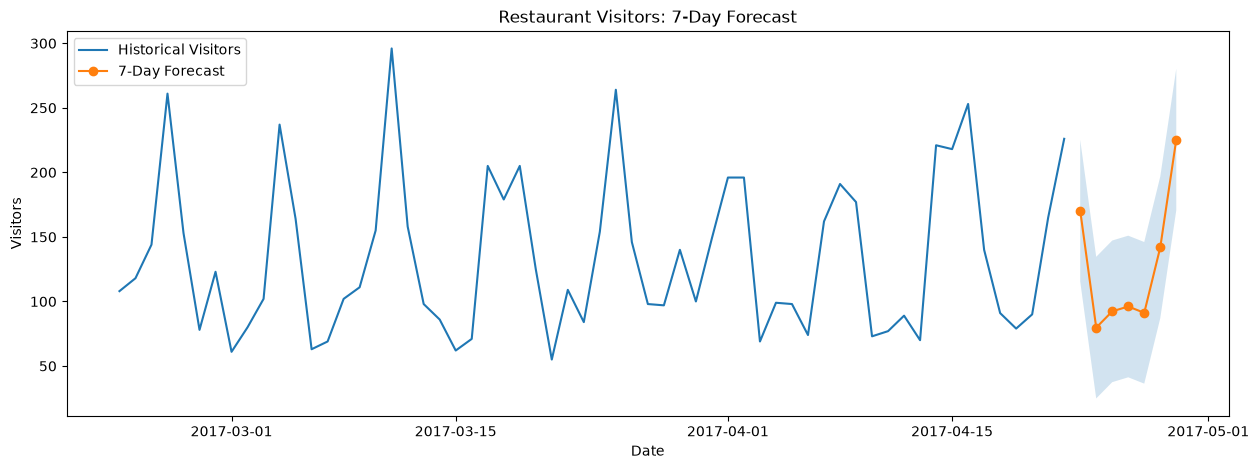

In [55]:
# 7 day forecast Visualize
plt.figure(figsize=(15, 5))

plt.plot(
    rv.index[-60:],
    rv['total'].iloc[-60:],
    label='Historical Visitors')

plt.plot(
    future_dates,
    forecast_mean,
    marker='o',
    label='7-Day Forecast')

plt.fill_between(
    future_dates,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2)

plt.title('Restaurant Visitors: 7-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Visitors')

plt.legend()
plt.show()

### Forecast Interpretation

The SARIMAX model forecasts varying visitor demand over the next seven days, with higher visitor counts expected toward the weekend.

The confidence intervals indicate the uncertainty associated with each forecast and provide a range of expected visitor counts.

These forecasts can support short-term staffing, inventory preparation, and operational planning.

# Business Impact

this model can help :

* Forecast expected customer demand
* Plan employee staffing
* Prepare inventory
* Reduce overstaffing/understaffing
* Improve operational planning
* Anticipate holiday-related demand changes

## Conclusion

The SARIMAX model successfully captured weekly seasonality in restaurant visitor patterns while incorporating holiday information as an exogenous variable.

Auto ARIMA was used to identify suitable SARIMA parameters, after which the selected configuration was implemented using SARIMAX.

The model achieved a MAPE of approximately 15.38% and MSE of approximately 546.06 on the 38-observation test set.

The results indicate that the model can provide useful short-term visitor forecasts that may support restaurant staffing, inventory management, and operational planning.

Future improvements could include incorporating additional external variables such as weather, promotions, local events, and reservation data.